In [1]:
# ambiente anaconda
import sys
print(sys.executable)

/home/fabiene/anaconda3/envs/Udemy/bin/python


In [2]:
# versão do python
print(sys.version)

3.11.9 (main, Apr 19 2024, 16:48:06) [GCC 11.2.0]


In [3]:
#from google.colab import drive
#drive.mount('/content/drive')

import os
# DRIVE_DIRECTORY = "curso_ml"
# DRIVE_DIRECTORY = os.path.join("/content/drive/MyDrive", DRIVE_DIRECTORY)

In [4]:
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from yellowbrick.classifier import ConfusionMatrix

In [5]:
DRIVE_DIRECTORY_fonte ='../../2-3-Classificacao/Exercicio_Faltante_Classificacao'
with open(os.path.join(DRIVE_DIRECTORY_fonte, "cover_type_exer3.pkl"), "rb") as f:
    (X_train, y_train, X_test, y_test) = pickle.load(f)

# Árvores de decisão

Comece recuperando os dados preditores, de treino e de teste, a partir do arquivo `cover_type.pkl` salvo na pasta do Drive. Lembre-se de que você deve instanciar as variáveis `X` e `y`, dos splits `train` e `test`,  na mesma ordem que salvou.

Use o atributo `shape` para verificar quantas instâncias e quantos atributos têm cada uma dessas variáveis.

In [6]:
X_train.shape, y_train.shape

((7500, 53), (7500,))

In [7]:
X_test.shape, y_test.shape

((2500, 53), (2500,))

Instancie e treine um classificador da classe `DecisionTreeClassifier`. Use o parâmetro `criterion='gini'` (valor padrão) e `random_state=0`.

In [8]:
# gini é o valor padrão
# DecisionTreeClassifier: Cria um fluxograma de decisões baseado nos dados.
# criterion='gini': Medida usada para escolher a melhor divisão dos ramos.
# fit: Constrói a árvore de cima para baixo (raiz até as folhas).

tree_classifier = DecisionTreeClassifier(criterion='gini', random_state=0)
tree_classifier.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
tree_classifier.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 0,
 'splitter': 'best'}

1. DecisionTreeClassifier(criterion='gini', random_state=0)
criterion='gini': O Gini é o cálculo matemático que a árvore usa para decidir qual pergunta fazer primeiro. Ele mede a "pureza" dos dados.

Se um grupo tem apenas árvores Aspen, o Gini é 0 (puro).

A árvore sempre escolhe a pergunta que divide os dados da forma mais organizada possível.

random_state=0: Garante que, se você rodar o código hoje ou amanhã, o resultado será o mesmo. Ele "trava" a aleatoriedade interna do algoritmo.

2. tree_classifier.fit(X_train, y_train)
Aqui é onde o "estudo" acontece. A árvore olha para as suas características (X_train) e cria uma sequência de regras lógicas:

A elevação é maior que 2500m? (Sim/Não)

Se sim, a inclinação (slope) é maior que 15°? (Sim/Não)

Se não, o solo é do tipo X? ...e assim por diante até classificar o Cover_Type.

## Calcule e exiba as predições feitas no split de teste.

In [10]:
# previsão
y_pred = tree_classifier.predict(X_test)
y_pred

array([4, 4, 1, ..., 6, 4, 5], shape=(2500,))

## Calcule a acurácia do classificador.

In [11]:
accuracy_score(y_test, y_pred)

0.7172

In [12]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100} % de acurácia ou acerto')

tivemos 71.72 % de acurácia ou acerto


## Exiba a matriz de confusão.

0.7172

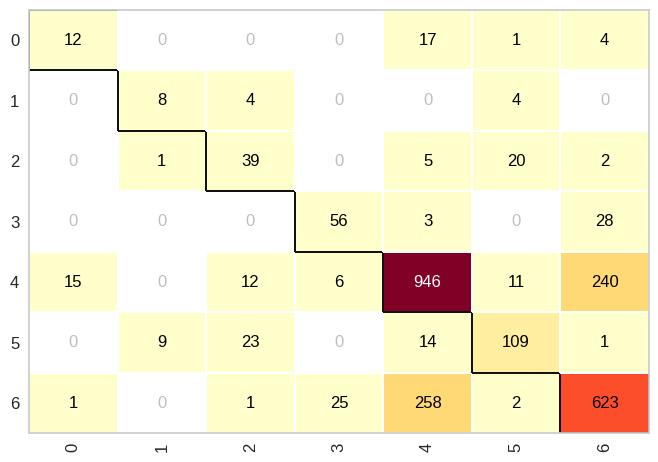

In [13]:
cm = ConfusionMatrix(tree_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [14]:
# classe com mais acerto é o número 4

Mapa de "Alvos vs. Tiros".

O objetivo é entender não apenas o quanto o modelo acerta, mas exatamente onde ele está se confundindo.

1. Os dois eixos principais
#### Eixo Vertical (True Class): É a realidade. O que a árvore realmente é no mundo real.

#### Eixo Horizontal (Predicted Class): É o palpite do modelo. O que o GaussianNB achou que era.

In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.43      0.35      0.39        34
           1       0.44      0.50      0.47        16
           2       0.49      0.58      0.53        67
           3       0.64      0.64      0.64        87
           4       0.76      0.77      0.77      1230
           5       0.74      0.70      0.72       156
           6       0.69      0.68      0.69       910

    accuracy                           0.72      2500
   macro avg       0.60      0.60      0.60      2500
weighted avg       0.72      0.72      0.72      2500



a classe 4 é a melhor, o ideal é a precision ser maior, assim como o recall

a pior classe é o 0, com precisão de 0,43

1. Precision (Precisão)
Pergunta: "De todas as vezes que o modelo disse que era Aspen, quantas eram realmente Aspen?"

Foco: Evitar alarmes falsos.

Se a precisão é 0.80, significa que quando o modelo aponta para uma árvore e diz "É Aspen", ele acerta 80% das vezes.

2. Recall (Revocação / Sensibilidade)
Pergunta: "De todas as árvores Aspen que existem de verdade no mato, quantas o modelo conseguiu encontrar?"

Foco: Não deixar passar nada.

Se o recall é 0.60, significa que o modelo só achou 60% das Aspens totais; as outras 40% ele confundiu com outro tipo.

3. F1-Score
O que é: Uma média (harmônica) entre a Precisão e o Recall.

Foco: Equilíbrio.

É a melhor métrica para olhar se você quer um resumo rápido, pois se a Precisão for ótima mas o Recall for péssimo (ou vice-versa), o F1-Score cai.

4. Support (Suporte)
O que é: A quantidade real de exemplos daquela classe no seu conjunto de testes.

Foco: Contexto.

Se o suporte de uma árvore é 10 e de outra é 5000, você sabe que o resultado da primeira não é tão confiável estatisticamente quanto o da segunda.

__A árvore de decisão já ficou muito melhor que o classificador bayesiano.__

## tentativa 2

Agora repita o exercício utilizando a classe `RandomForestClassifier`. Nós não vamos informar `n_estimators` (o algoritmo vai utilizar o valor padrão de 100), nem `criterion` (o padrão é Gini). Para garantir reprodutibilidade, informe `random_state=0`.

In [16]:
tree_classifier = RandomForestClassifier(random_state=0)
tree_classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
tree_classifier.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 0,
 'verbose': 0,
 'warm_start': False}

In [18]:
y_pred = tree_classifier.predict(X_test)
y_pred

array([4, 4, 5, ..., 6, 6, 2], shape=(2500,))

In [19]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100} % de acurácia ou acerto')

tivemos 80.64 % de acurácia ou acerto


0.8064

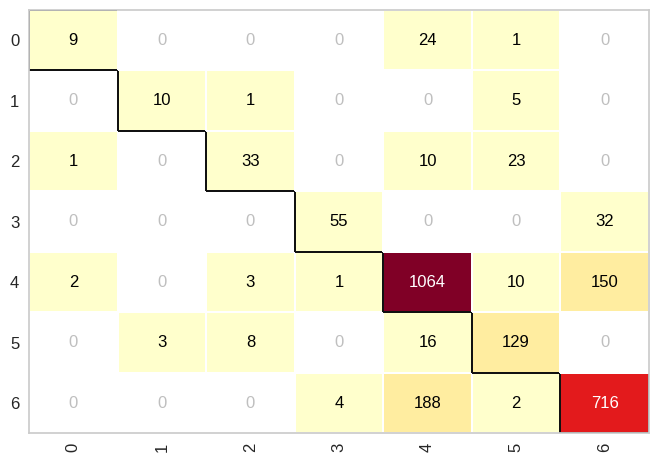

In [20]:
cm = ConfusionMatrix(tree_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.26      0.39        34
           1       0.77      0.62      0.69        16
           2       0.73      0.49      0.59        67
           3       0.92      0.63      0.75        87
           4       0.82      0.87      0.84      1230
           5       0.76      0.83      0.79       156
           6       0.80      0.79      0.79       910

    accuracy                           0.81      2500
   macro avg       0.79      0.64      0.69      2500
weighted avg       0.81      0.81      0.80      2500



agora o precision 0 é maior que 70%, e melhorou mais o 4

In [23]:
from sklearn.preprocessing import LabelEncoder

# # 1. Recriamos o objeto
# label_encoder = LabelEncoder()

# # 2. "Ensinamos" a ele os nomes novamente usando a coluna original do DataFrame
# # Isso restaura a memória do encoder (o mapeamento de nomes para números)
# label_encoder.fit(base['Cover_Type'])

# # 3. Agora o comando vai funcionar!
# y_pred_strings = label_encoder.inverse_transform(y_pred)
# y_test_strings = label_encoder.inverse_transform(y_test)

# print("Nomes traduzidos com sucesso!")
# print(label_encoder.classes_)

#---------------------------------------

# # 1. Primeiro, geramos as previsões (que virão como números: 0, 1, 2...)
# y_pred = naive_classifier.predict(X_test)

# # 2. Agora, traduzimos os números de volta para os nomes das árvores
# y_pred_strings = label_encoder.inverse_transform(y_pred)

# # 3. Fazemos o mesmo para o y_test para podermos comparar "Nome vs Nome"
# y_test_strings = label_encoder.inverse_transform(y_test)

# # 4. Criamos uma tabela para você ver os 10 primeiros resultados reais
# import pandas as pd
# df_resultados = pd.DataFrame({
#     'Classe Real': y_test_strings,
#     'Previsão do Modelo': y_pred_strings
# })

# print("--- Primeiros 10 resultados traduzidos ---")
# print(df_resultados.head(10))
#----------------------------------

# # 1. Converte o array de números (y_pred) para os nomes originais (strings)
# y_pred_nomes = label_encoder.inverse_transform(y_pred)

# # 2. Se quiser ver os nomes reais do conjunto de teste para comparar
# y_test_nomes = label_encoder.inverse_transform(y_test)

# # 3. Vamos ver os 10 primeiros resultados lado a lado
# import pandas as pd
# comparacao = pd.DataFrame({
#     'Real': y_test_nomes,
#     'Previsão': y_pred_nomes
# })

# print(comparacao.head(10))

# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb


In [24]:
# no arquivo original => M3_Exercicio_classificacao_pre_processamento_dos_dados.ipynb
# y = base.iloc[:, -1].values
# base.columns[-1] # a coluna de interesse, o target, ou seja a classe é esta
# 'Cover_Type'

# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)
# # Mostra a lista de nomes na ordem (0, 1, 2...)
# print(label_encoder.classes_)
# {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 6: 'Spruce/Fir'}



In [25]:
import pandas as pd

# O seu dicionário de mapeamento
mapa_nomes = {0: 'Aspen', 1: 'Cottonwood/Willow', 2: 'Douglas-fir', 
              3: 'Krummholz', 4: 'Lodgepole Pine', 5: 'Ponderosa Pine', 
              6: 'Spruce/Fir'}

# Criando o DataFrame de comparação
df_comparacao = pd.DataFrame({
    'Real': y_test,
    'Previsão': y_pred
})

# Traduzindo as colunas usando o dicionário
df_comparacao['Real_Nome'] = df_comparacao['Real'].map(mapa_nomes)
df_comparacao['Previsao_Nome'] = df_comparacao['Previsão'].map(mapa_nomes)

display(df_comparacao[['Real_Nome', 'Previsao_Nome']].head(10))

,Real_Nome,Previsao_Nome
0,Lodgepole Pine,Lodgepole Pine
1,Lodgepole Pine,Lodgepole Pine
2,Cottonwood/Willow,Ponderosa Pine
3,Lodgepole Pine,Lodgepole Pine
4,Lodgepole Pine,Lodgepole Pine
5,Spruce/Fir,Spruce/Fir
6,Lodgepole Pine,Lodgepole Pine
7,Spruce/Fir,Spruce/Fir
8,Lodgepole Pine,Lodgepole Pine
9,Lodgepole Pine,Lodgepole Pine


---

## Tentativa 3,novo algoritmo

Randomforecast é a combinação de árvores de decisão

**EXTRA**

[Consulte a documentação](https://scikit-learn.org/stable/api/sklearn.ensemble.html) e escolha um outro classificador do tipo *ensemble* para treinar. Observação: pode ser que nem todos os classificadores funcionem, pois eles podem ter restrições quanto ao formato dos dados apresentados.

Abaixo como exemplo está o `GradientBoostingClassifier`.

In [26]:
from sklearn.ensemble import GradientBoostingClassifier

tree_classifier = GradientBoostingClassifier(random_state=0)
tree_classifier.fit(X_train, y_train)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [27]:
tree_classifier.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 0,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [28]:
y_pred = tree_classifier.predict(X_test)

In [30]:
y_pred

array([4, 4, 1, ..., 6, 6, 5], shape=(2500,))

In [29]:
print(f'tivemos {accuracy_score(y_test, y_pred)*100} % de acurácia ou acerto')

tivemos 75.24 % de acurácia ou acerto


0.7524

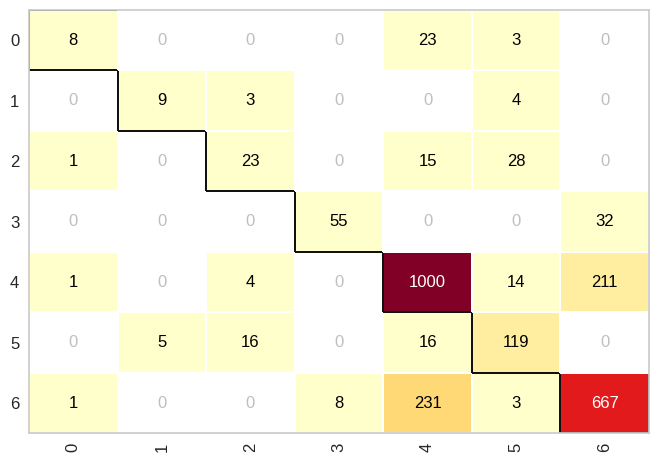

In [31]:
cm = ConfusionMatrix(tree_classifier)
cm.fit(X_train, y_train)
cm.score(X_test, y_test)

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.24      0.36        34
           1       0.64      0.56      0.60        16
           2       0.50      0.34      0.41        67
           3       0.87      0.63      0.73        87
           4       0.78      0.81      0.80      1230
           5       0.70      0.76      0.73       156
           6       0.73      0.73      0.73       910

    accuracy                           0.75      2500
   macro avg       0.71      0.58      0.62      2500
weighted avg       0.75      0.75      0.75      2500

